## Imports


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import re

## Global Settings


In [2]:
SEED = 761
np.random.seed(SEED)
EPS = 1e-8
PLOTS_DIR = Path.cwd() / 'plots'
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
PLOT_INDEX = 0

def plot_file_name(title):
    global PLOT_INDEX
    PLOT_INDEX += 1
    safe = re.sub(r'[^A-Za-z0-9._-]+', '_', title).strip('_')
    return PLOTS_DIR / f'{PLOT_INDEX:02d}_{safe}.png'


## Common Utilities


In [3]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def relu(z):
    return np.maximum(0.0, z)

def d_sigmoid(a):
    return a * (1.0 - a)

def d_relu(z):
    return (z > 0).astype(float)

def bce_loss(y_hat, y):
    y_hat = np.clip(y_hat, EPS, 1.0 - EPS)
    return -np.mean(y * np.log(y_hat) + (1.0 - y) * np.log(1.0 - y_hat))

def binary_acc(y_hat, y):
    pred = (y_hat >= 0.5).astype(int)
    return np.mean(pred == y)

def split_70_15_15(X, y, seed=761):
    n = X.shape[0]
    rng = np.random.default_rng(seed)
    idx = rng.permutation(n)
    n_train = int(0.70 * n)
    n_val = int(0.15 * n)
    train_idx = idx[:n_train]
    val_idx = idx[n_train:n_train + n_val]
    test_idx = idx[n_train + n_val:]
    return X[train_idx], y[train_idx], X[val_idx], y[val_idx], X[test_idx], y[test_idx]

def grad_fro_norm(g):
    return np.sqrt(np.sum(g * g))

def plot_history(history, title_prefix):
    ep = np.arange(1, len(history['train_loss']) + 1)
    fig, ax = plt.subplots(2, 2, figsize=(10, 7))
    ax[0,0].plot(ep, history['train_loss'])
    ax[0,0].set_title('Training Loss vs Epoch')
    ax[0,1].plot(ep, history['val_loss'])
    ax[0,1].set_title('Validation Loss vs Epoch')
    ax[1,0].plot(ep, history['train_acc'])
    ax[1,0].set_title('Training Accuracy vs Epoch')
    ax[1,1].plot(ep, history['val_acc'])
    ax[1,1].set_title('Validation Accuracy vs Epoch')
    fig.suptitle(title_prefix)
    plt.tight_layout()
    file_path = plot_file_name(title_prefix)
    fig.savefig(file_path, dpi=150, bbox_inches='tight')
    print(f'Saved plot: {file_path}')
    plt.show()



## Part 1: Deep Networks on Numeric Data
Dataset


In [4]:
N = 3000
x1 = np.random.uniform(-2.0, 2.0, (N, 1))
x2 = np.random.uniform(-2.0, 2.0, (N, 1))
X_num = np.hstack([x1, x2])
y_num = ((x1**2 + x2**2) > 1.5).astype(int)
Xtr_num, ytr_num, Xval_num, yval_num, Xte_num, yte_num = split_70_15_15(X_num, y_num, seed=SEED)
Xtr_num.shape, Xval_num.shape, Xte_num.shape


((2100, 2), (450, 2), (450, 2))

### Task 1A: Build Dense Architectures
2-layer, 5-layer, 10-layer


In [5]:
def init_dense(layer_sizes, seed=761):
    rng = np.random.default_rng(seed)
    params = []
    for i in range(len(layer_sizes) - 1):
        n_in = layer_sizes[i]
        n_out = layer_sizes[i + 1]
        W = rng.uniform(-1.0, 1.0, size=(n_in, n_out))
        b = np.zeros((1, n_out))
        params.append({'W': W, 'b': b})
    return params

def forward_dense(X, params, hidden_activation='relu'):
    a = X
    caches = []
    L = len(params)
    for i in range(L):
        W = params[i]['W']
        b = params[i]['b']
        z = a @ W + b
        if i == L - 1:
            a_next = sigmoid(z)
        else:
            if hidden_activation == 'relu':
                a_next = relu(z)
            else:
                a_next = sigmoid(z)
        caches.append({'a_in': a, 'z': z, 'a': a_next})
        a = a_next
    return a, caches

def backward_dense(y_hat, y, caches, params, hidden_activation='relu'):
    grads = [None] * len(params)
    m = y.shape[0]
    dz = (y_hat - y) / m
    for i in range(len(params) - 1, -1, -1):
        a_in = caches[i]['a_in']
        dW = a_in.T @ dz
        db = np.sum(dz, axis=0, keepdims=True)
        grads[i] = {'dW': dW, 'db': db}
        if i > 0:
            da_prev = dz @ params[i]['W'].T
            z_prev = caches[i - 1]['z']
            if hidden_activation == 'relu':
                dz = da_prev * d_relu(z_prev)
            else:
                a_prev = caches[i - 1]['a']
                dz = da_prev * d_sigmoid(a_prev)
    return grads

def dense_param_count(layer_sizes):
    total = 0
    for i in range(len(layer_sizes) - 1):
        n_in = layer_sizes[i]
        n_out = layer_sizes[i + 1]
        total += (n_in * n_out) + n_out
    return total


### Task 1B: Parameter Calculation


In [6]:
def show_param_derivation(layer_sizes):
    vals = []
    for i in range(len(layer_sizes) - 1):
        n_in = layer_sizes[i]
        n_out = layer_sizes[i + 1]
        vals.append((n_in, n_out, (n_in * n_out) + n_out))
    for i, (n_in, n_out, c) in enumerate(vals, 1):
        print(f'Layer {i}: ({n_in} x {n_out}) + {n_out} = {c}')
    print('Total:', sum(v[2] for v in vals))

for d in [2, 5, 10]:
    sizes = [2] + [4] * (d - 1) + [1]
    print('Depth', d)
    show_param_derivation(sizes)
    print()


Depth 2
Layer 1: (2 x 4) + 4 = 12
Layer 2: (4 x 1) + 1 = 5
Total: 17

Depth 5
Layer 1: (2 x 4) + 4 = 12
Layer 2: (4 x 4) + 4 = 20
Layer 3: (4 x 4) + 4 = 20
Layer 4: (4 x 4) + 4 = 20
Layer 5: (4 x 1) + 1 = 5
Total: 77

Depth 10
Layer 1: (2 x 4) + 4 = 12
Layer 2: (4 x 4) + 4 = 20
Layer 3: (4 x 4) + 4 = 20
Layer 4: (4 x 4) + 4 = 20
Layer 5: (4 x 4) + 4 = 20
Layer 6: (4 x 4) + 4 = 20
Layer 7: (4 x 4) + 4 = 20
Layer 8: (4 x 4) + 4 = 20
Layer 9: (4 x 4) + 4 = 20
Layer 10: (4 x 1) + 1 = 5
Total: 177



### Task 1C: Optimizer Comparison


In [7]:
def train_dense(Xtr, ytr, Xval, yval, layer_sizes, hidden_activation='relu', optimizer='sgd', lr=0.05, epochs=300, beta=0.9, seed=761, track_grad=False):
    params = init_dense(layer_sizes, seed=seed)
    vel = [{'W': np.zeros_like(p['W']), 'b': np.zeros_like(p['b'])} for p in params]
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    if track_grad:
        history['grad_first'] = []
        history['grad_last'] = []
    for _ in range(epochs):
        y_hat, caches = forward_dense(Xtr, params, hidden_activation=hidden_activation)
        grads = backward_dense(y_hat, ytr, caches, params, hidden_activation=hidden_activation)
        if optimizer == 'sgd':
            for i in range(len(params)):
                params[i]['W'] -= lr * grads[i]['dW']
                params[i]['b'] -= lr * grads[i]['db']
        else:
            for i in range(len(params)):
                vel[i]['W'] = beta * vel[i]['W'] + lr * grads[i]['dW']
                vel[i]['b'] = beta * vel[i]['b'] + lr * grads[i]['db']
                params[i]['W'] -= vel[i]['W']
                params[i]['b'] -= vel[i]['b']
        tr_hat, _ = forward_dense(Xtr, params, hidden_activation=hidden_activation)
        va_hat, _ = forward_dense(Xval, params, hidden_activation=hidden_activation)
        history['train_loss'].append(bce_loss(tr_hat, ytr))
        history['val_loss'].append(bce_loss(va_hat, yval))
        history['train_acc'].append(binary_acc(tr_hat, ytr))
        history['val_acc'].append(binary_acc(va_hat, yval))
        if track_grad:
            history['grad_first'].append(grad_fro_norm(grads[0]['dW']))
            history['grad_last'].append(grad_fro_norm(grads[-1]['dW']))
    return params, history

def eval_dense(X, y, params, hidden_activation='relu'):
    y_hat, _ = forward_dense(X, params, hidden_activation=hidden_activation)
    return bce_loss(y_hat, y), binary_acc(y_hat, y)


Saved plot: d:\Deep Learning\Deep-Learning-Lab\LAB_7\plots\01_Part1_Dense_2L_sigmoid_sgd.png


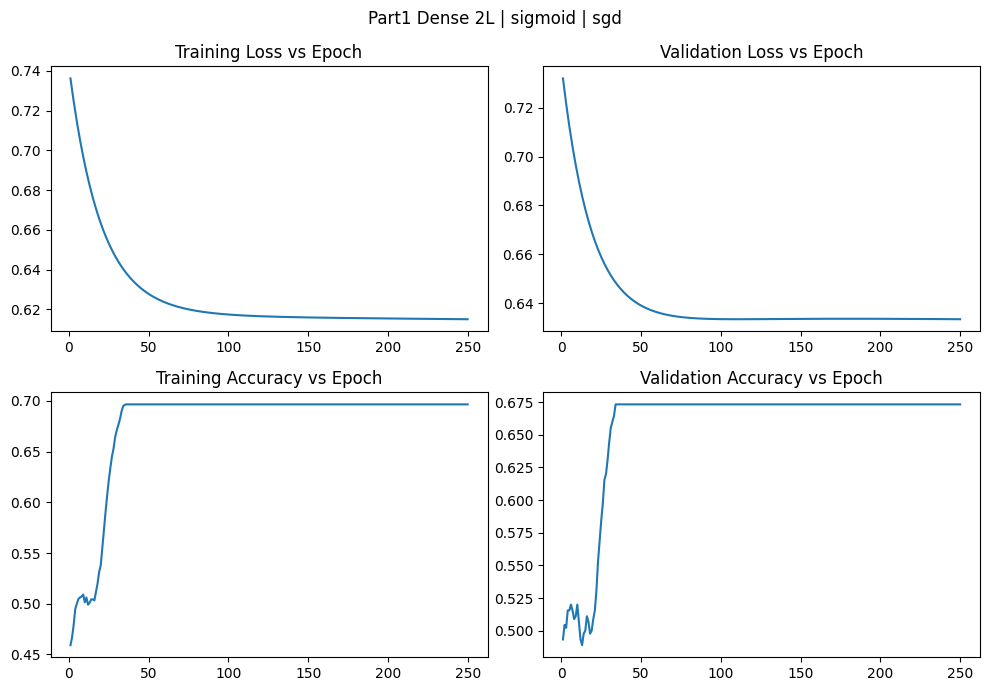

Saved plot: d:\Deep Learning\Deep-Learning-Lab\LAB_7\plots\02_Part1_Dense_2L_sigmoid_momentum.png


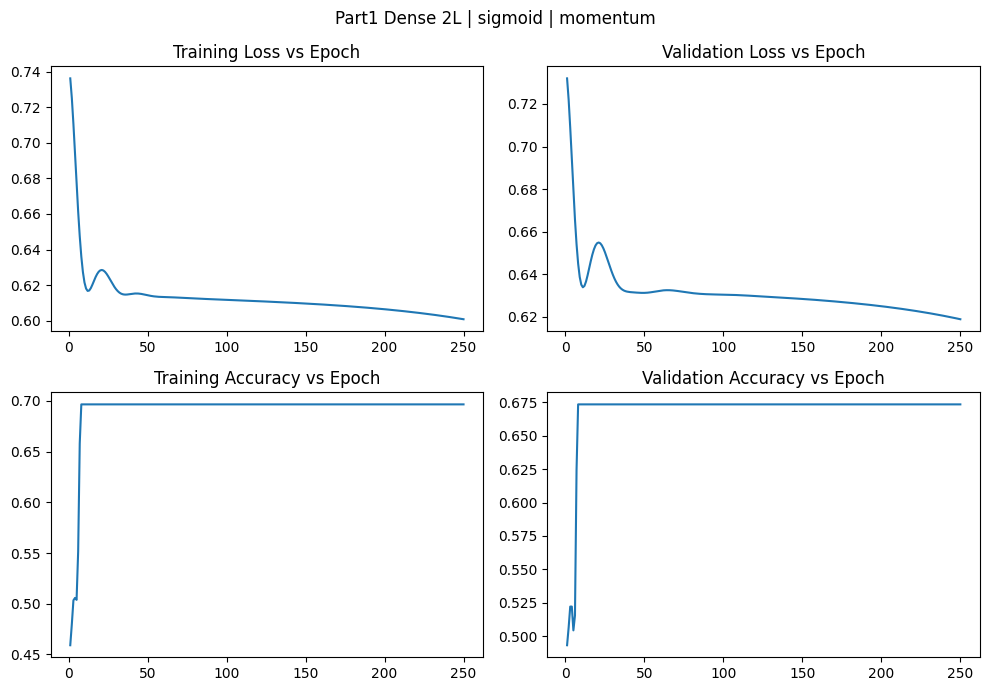

Saved plot: d:\Deep Learning\Deep-Learning-Lab\LAB_7\plots\03_Part1_Dense_2L_relu_sgd.png


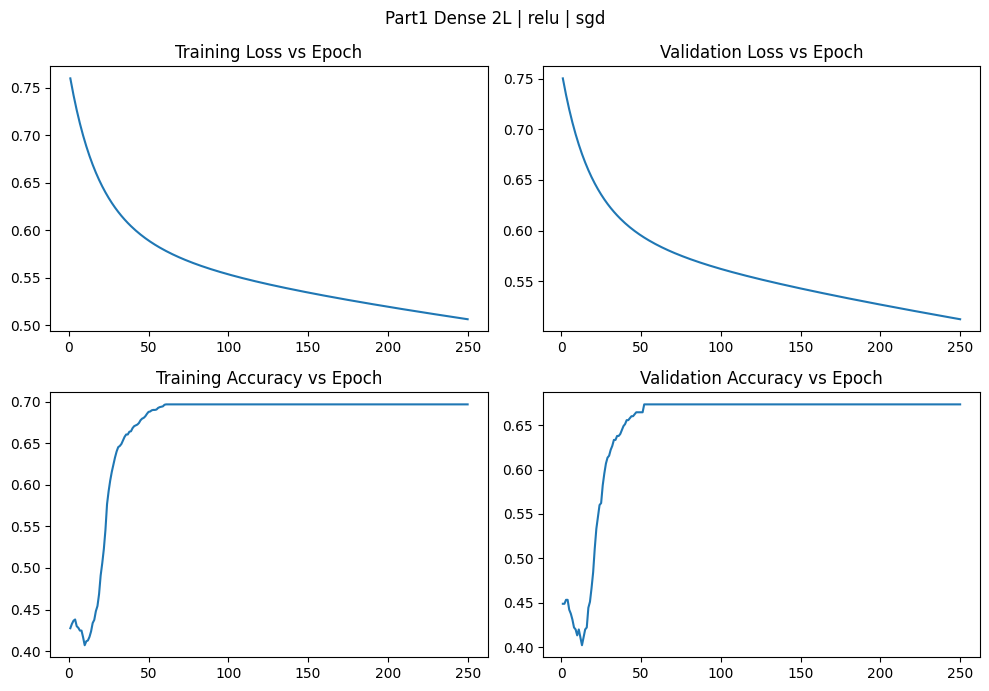

Saved plot: d:\Deep Learning\Deep-Learning-Lab\LAB_7\plots\04_Part1_Dense_2L_relu_momentum.png


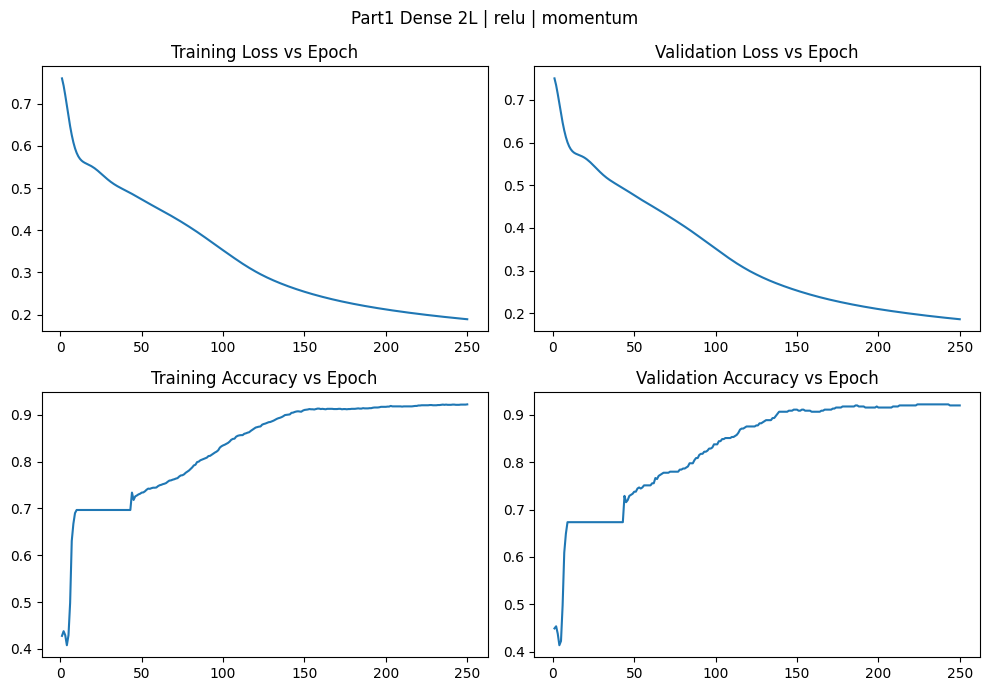

Saved plot: d:\Deep Learning\Deep-Learning-Lab\LAB_7\plots\05_Part1_Dense_5L_sigmoid_sgd.png


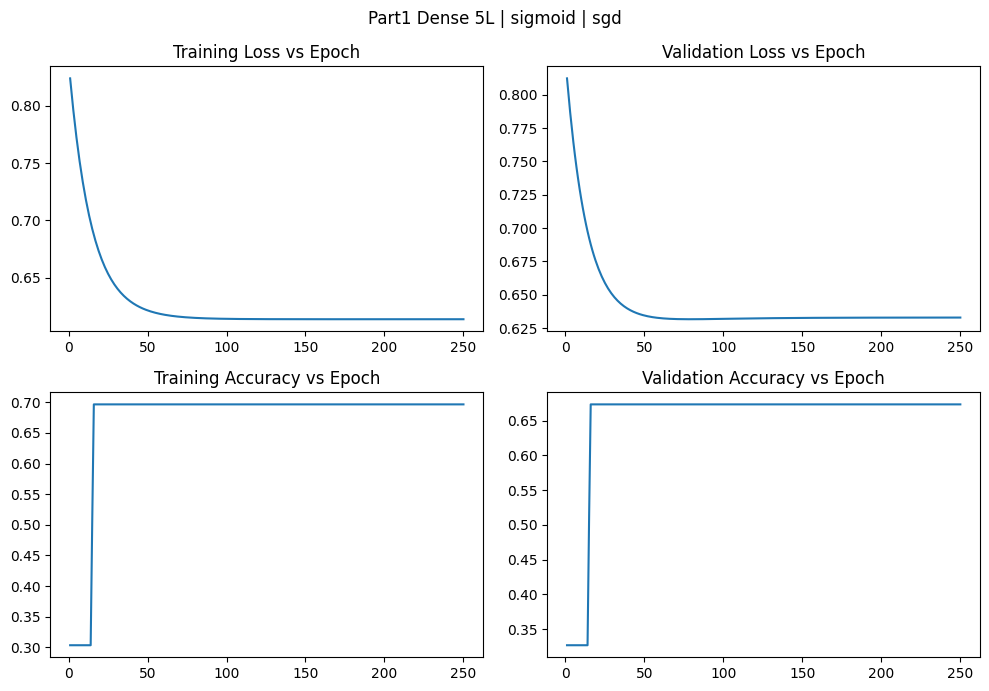

Saved plot: d:\Deep Learning\Deep-Learning-Lab\LAB_7\plots\06_Part1_Dense_5L_sigmoid_momentum.png


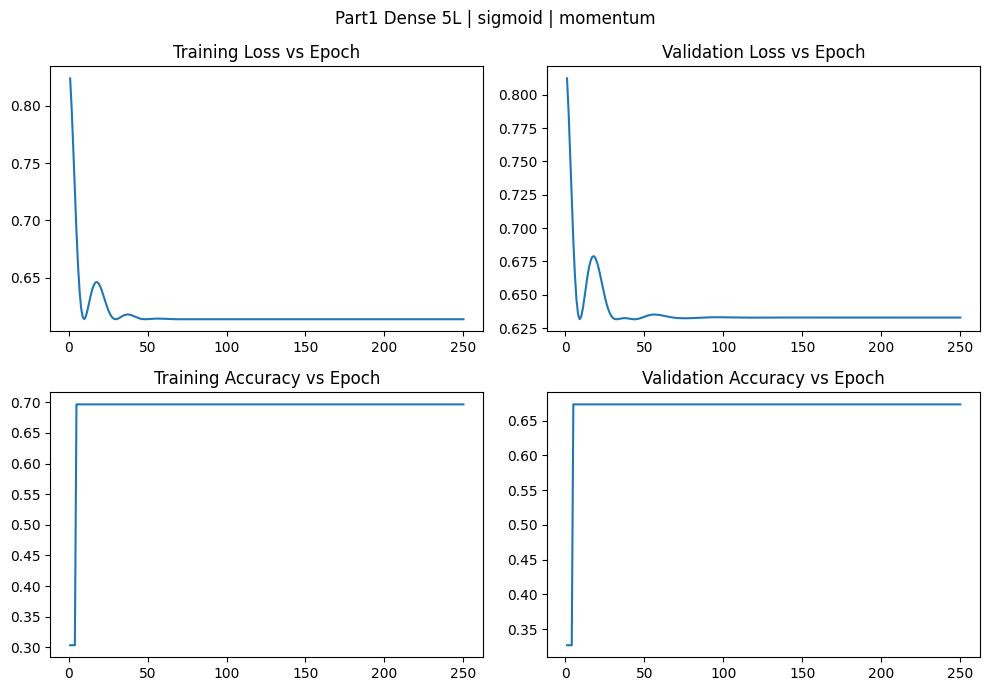

Saved plot: d:\Deep Learning\Deep-Learning-Lab\LAB_7\plots\07_Part1_Dense_5L_relu_sgd.png


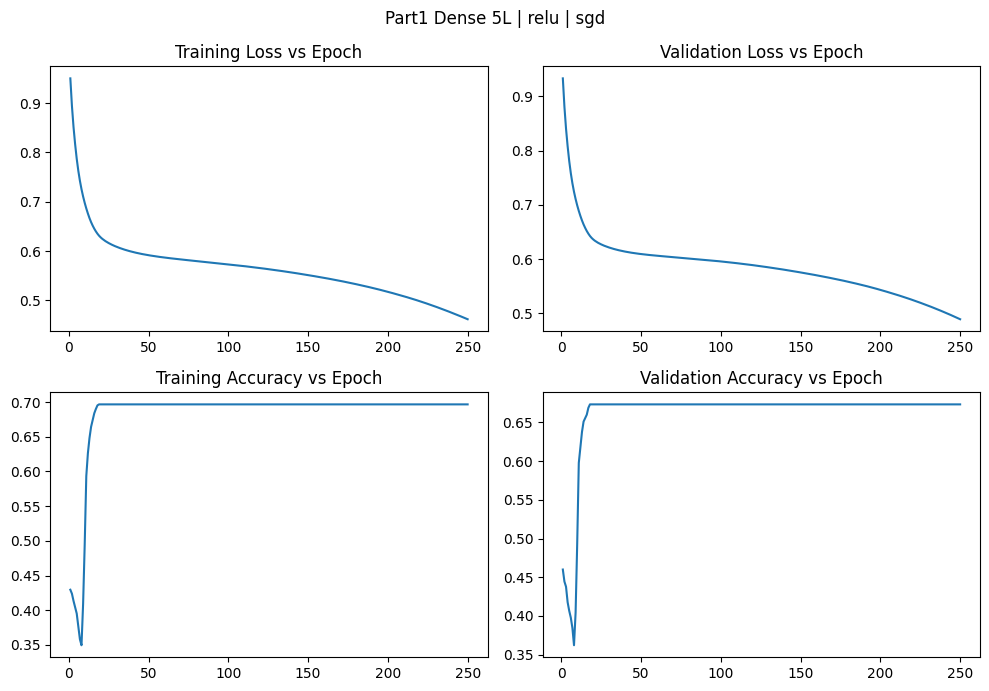

Saved plot: d:\Deep Learning\Deep-Learning-Lab\LAB_7\plots\08_Part1_Dense_5L_relu_momentum.png


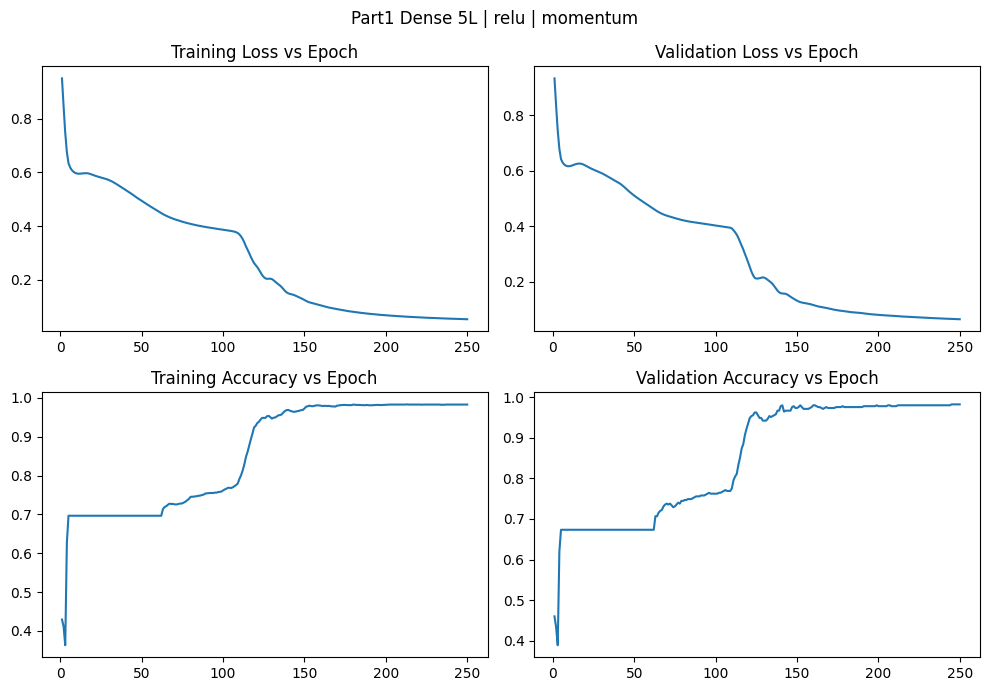

Saved plot: d:\Deep Learning\Deep-Learning-Lab\LAB_7\plots\09_Part1_Dense_10L_sigmoid_sgd.png


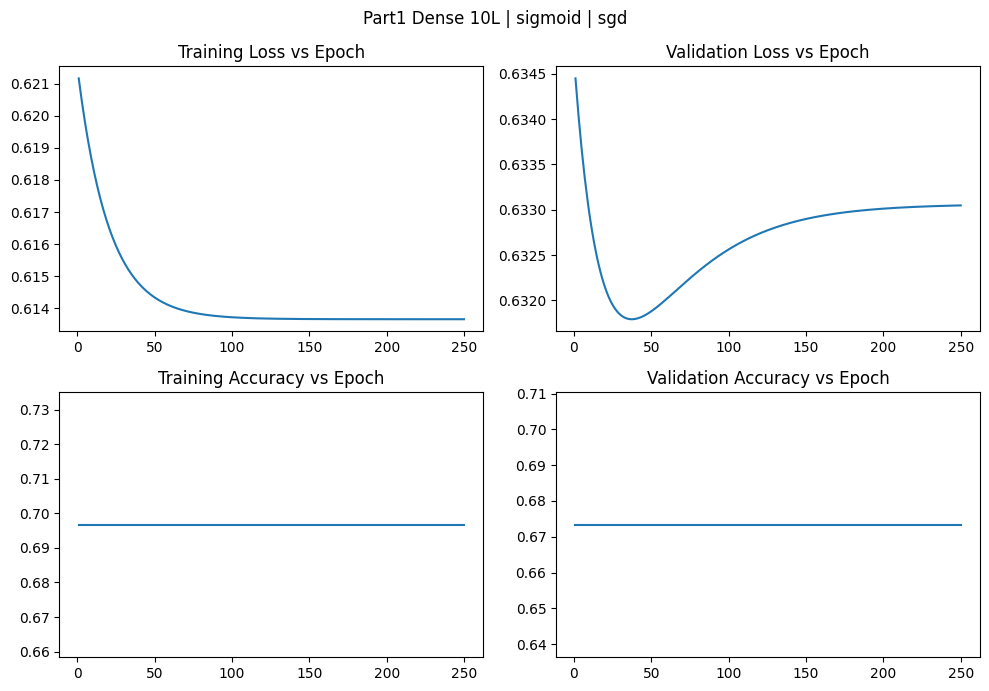

Saved plot: d:\Deep Learning\Deep-Learning-Lab\LAB_7\plots\10_Part1_Dense_10L_sigmoid_momentum.png


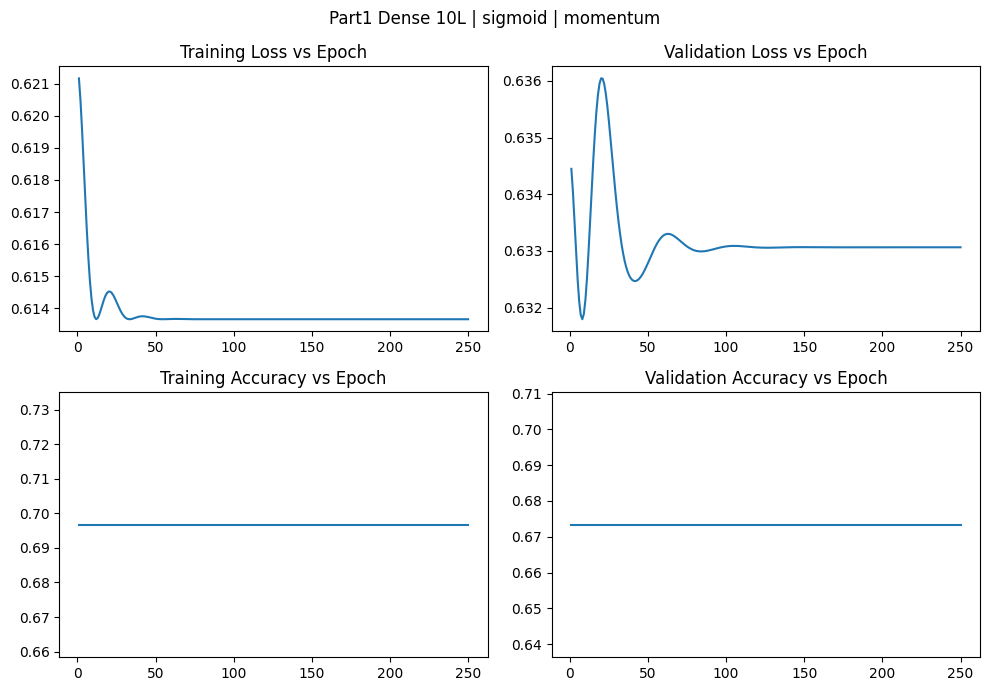

Saved plot: d:\Deep Learning\Deep-Learning-Lab\LAB_7\plots\11_Part1_Dense_10L_relu_sgd.png


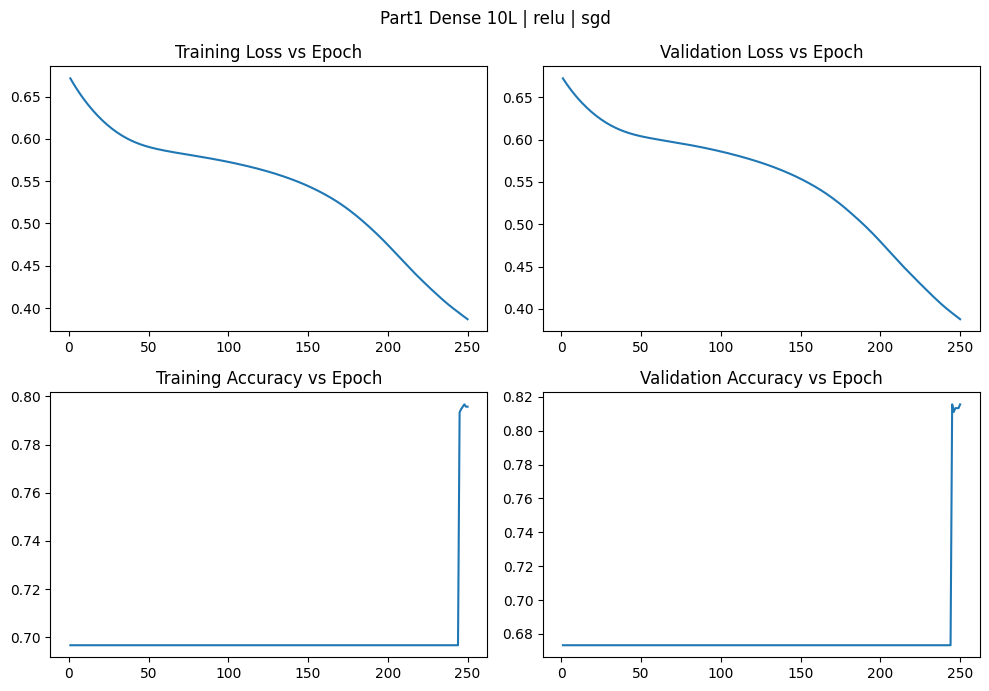

Saved plot: d:\Deep Learning\Deep-Learning-Lab\LAB_7\plots\12_Part1_Dense_10L_relu_momentum.png


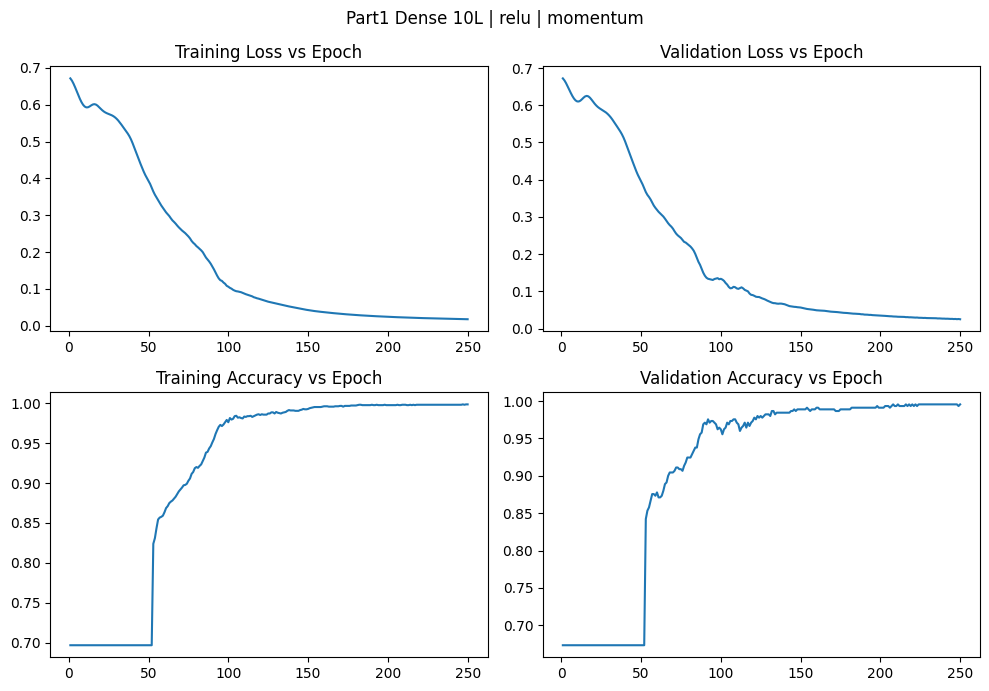

In [8]:
depths = [2, 5, 10]
activations = ['sigmoid', 'relu']
optimizers = ['sgd', 'momentum']
part1_results = []
part1_histories = {}

for depth in depths:
    for act in activations:
        for opt in optimizers:
            sizes = [2] + [4] * (depth - 1) + [1]
            track = (act == 'sigmoid' and depth in [2, 10])
            params, hist = train_dense(
                Xtr_num, ytr_num, Xval_num, yval_num,
                layer_sizes=sizes,
                hidden_activation=act,
                optimizer=opt,
                lr=0.05,
                epochs=250,
                beta=0.9,
                seed=SEED + depth,
                track_grad=track
            )
            tr_loss, tr_acc = eval_dense(Xtr_num, ytr_num, params, hidden_activation=act)
            va_loss, va_acc = eval_dense(Xval_num, yval_num, params, hidden_activation=act)
            te_loss, te_acc = eval_dense(Xte_num, yte_num, params, hidden_activation=act)
            rec = {
                'Model': f'Dense-{depth}L',
                'Depth': depth,
                'Activation': act,
                'Optimizer': opt,
                'Parameters': dense_param_count(sizes),
                'Train Acc': tr_acc,
                'Val Acc': va_acc,
                'Test Acc': te_acc,
                'Train Loss': tr_loss,
                'Val Loss': va_loss,
                'Test Loss': te_loss
            }
            part1_results.append(rec)
            part1_histories[(depth, act, opt)] = hist
            plot_history(hist, f'Part1 Dense {depth}L | {act} | {opt}')


### Add-On: Gradient Norm (Sigmoid 2-layer vs 10-layer)


Saved plot: d:\Deep Learning\Deep-Learning-Lab\LAB_7\plots\13_Gradient_Norms_Sigmoid_Depth_2.png


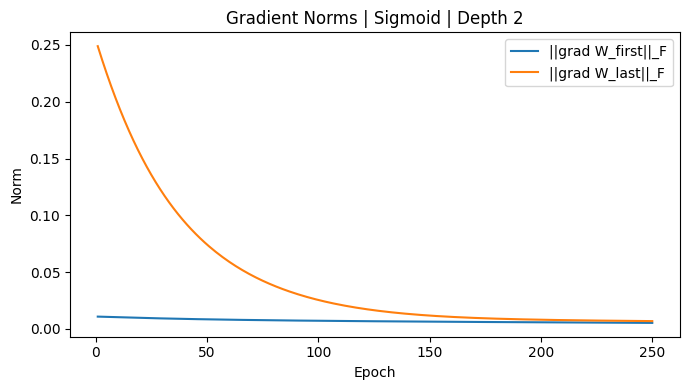

Saved plot: d:\Deep Learning\Deep-Learning-Lab\LAB_7\plots\14_Gradient_Norms_Sigmoid_Depth_10.png


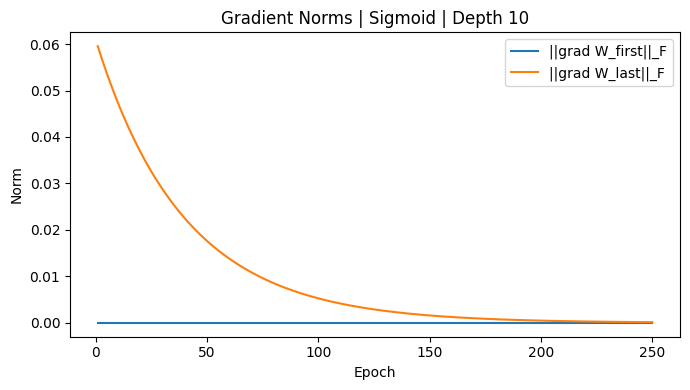

In [9]:
for depth in [2, 10]:
    key = (depth, 'sigmoid', 'sgd')
    if key in part1_histories and 'grad_first' in part1_histories[key]:
        h = part1_histories[key]
        ep = np.arange(1, len(h['grad_first']) + 1)
        plt.figure(figsize=(7, 4))
        plt.plot(ep, h['grad_first'], label='||grad W_first||_F')
        plt.plot(ep, h['grad_last'], label='||grad W_last||_F')
        plt.title(f'Gradient Norms | Sigmoid | Depth {depth}')
        plt.xlabel('Epoch')
        plt.ylabel('Norm')
        plt.legend()
        plt.tight_layout()
        file_path = plot_file_name(f'Gradient_Norms_Sigmoid_Depth_{depth}')
        plt.savefig(file_path, dpi=150, bbox_inches='tight')
        print(f'Saved plot: {file_path}')
        plt.show()



## Part 2: From Dense to Convolution
Option A: Synthetic 8x8 Images


In [10]:
def make_synth_8x8(n=3000, sigma=0.1, seed=761):
    rng = np.random.default_rng(seed)
    y = rng.integers(0, 2, size=(n, 1))
    X = np.zeros((n, 1, 8, 8), dtype=float)
    for i in range(n):
        if y[i, 0] == 0:
            X[i, 0, :, 4] = 1.0
        else:
            X[i, 0, 4, :] = 1.0
    X = X + rng.normal(0.0, sigma, size=X.shape)
    return X, y

X_img, y_img = make_synth_8x8(n=3000, sigma=0.1, seed=SEED)
Xtr_img, ytr_img, Xval_img, yval_img, Xte_img, yte_img = split_70_15_15(X_img, y_img, seed=SEED)
Xtr_img.shape, Xval_img.shape, Xte_img.shape


((2100, 1, 8, 8), (450, 1, 8, 8), (450, 1, 8, 8))

### Task 2A: Dense Baseline


Saved plot: d:\Deep Learning\Deep-Learning-Lab\LAB_7\plots\15_Part2_Dense_Baseline.png


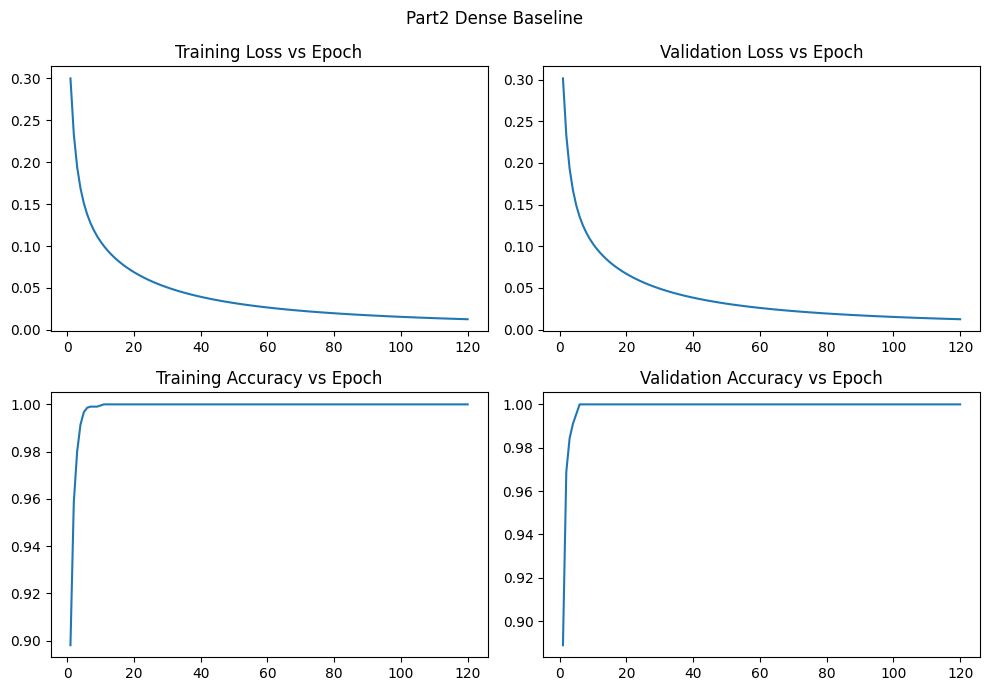

((np.float64(0.012757308562952572), np.float64(1.0)),
 (np.float64(0.012441905520253269), np.float64(1.0)),
 (np.float64(0.011869483870091261), np.float64(1.0)),
 1057)

In [11]:
Xtr_flat = Xtr_img.reshape(Xtr_img.shape[0], -1)
Xval_flat = Xval_img.reshape(Xval_img.shape[0], -1)
Xte_flat = Xte_img.reshape(Xte_img.shape[0], -1)
dense2_sizes = [64, 16, 1]
dense2_params, dense2_hist = train_dense(Xtr_flat, ytr_img, Xval_flat, yval_img, dense2_sizes, hidden_activation='relu', optimizer='sgd', lr=0.05, epochs=120, beta=0.9, seed=SEED)
plot_history(dense2_hist, 'Part2 Dense Baseline')
dense2_tr = eval_dense(Xtr_flat, ytr_img, dense2_params, hidden_activation='relu')
dense2_val = eval_dense(Xval_flat, yval_img, dense2_params, hidden_activation='relu')
dense2_te = eval_dense(Xte_flat, yte_img, dense2_params, hidden_activation='relu')
dense2_params_count = dense_param_count(dense2_sizes)
dense2_tr, dense2_val, dense2_te, dense2_params_count


### Task 2B: Build CNN From Scratch


In [12]:
def conv_forward(X, K, b):
    N, C, H, W = X.shape
    Cout, Cin, F, _ = K.shape
    Ho = H - F + 1
    Wo = W - F + 1
    out = np.zeros((N, Cout, Ho, Wo))
    for n in range(N):
        for co in range(Cout):
            for i in range(Ho):
                for j in range(Wo):
                    s = 0.0
                    for ci in range(Cin):
                        s += np.sum(X[n, ci, i:i+F, j:j+F] * K[co, ci])
                    out[n, co, i, j] = s + b[co, 0]
    cache = (X, K, b)
    return out, cache

def conv_backward(dout, cache):
    X, K, b = cache
    N, C, H, W = X.shape
    Cout, Cin, F, _ = K.shape
    Ho = H - F + 1
    Wo = W - F + 1
    dX = np.zeros_like(X)
    dK = np.zeros_like(K)
    db = np.zeros_like(b)
    for n in range(N):
        for co in range(Cout):
            for i in range(Ho):
                for j in range(Wo):
                    g = dout[n, co, i, j]
                    db[co, 0] += g
                    for ci in range(Cin):
                        dK[co, ci] += X[n, ci, i:i+F, j:j+F] * g
                        dX[n, ci, i:i+F, j:j+F] += K[co, ci] * g
    return dX, dK, db

def relu_forward(x):
    out = np.maximum(0.0, x)
    return out, x

def relu_backward(dout, cache):
    x = cache
    return dout * (x > 0)

def maxpool_forward(x, size=2, stride=2):
    N, C, H, W = x.shape
    Ho = (H - size) // stride + 1
    Wo = (W - size) // stride + 1
    out = np.zeros((N, C, Ho, Wo))
    mask = np.zeros_like(x)
    for n in range(N):
        for c in range(C):
            for i in range(Ho):
                for j in range(Wo):
                    hs = i * stride
                    ws = j * stride
                    patch = x[n, c, hs:hs+size, ws:ws+size]
                    m = np.max(patch)
                    out[n, c, i, j] = m
                    idx = np.unravel_index(np.argmax(patch), patch.shape)
                    mask[n, c, hs + idx[0], ws + idx[1]] = 1
    cache = (x, mask, size, stride)
    return out, cache

def maxpool_backward(dout, cache):
    x, mask, size, stride = cache
    N, C, H, W = x.shape
    Ho, Wo = dout.shape[2], dout.shape[3]
    dx = np.zeros_like(x)
    for n in range(N):
        for c in range(C):
            for i in range(Ho):
                for j in range(Wo):
                    hs = i * stride
                    ws = j * stride
                    patch_mask = mask[n, c, hs:hs+size, ws:ws+size]
                    dx[n, c, hs:hs+size, ws:ws+size] += patch_mask * dout[n, c, i, j]
    return dx

def dropout_forward(x, p=0.5, train=True, seed=None):
    if not train:
        return x, None
    rng = np.random.default_rng(seed)
    m = (rng.random(x.shape) < p).astype(float) / p
    return x * m, m

def dropout_backward(dout, mask):
    if mask is None:
        return dout
    return dout * mask


In [13]:
def init_cnn(c_in=1, c_out=4, f=3, with_pool=True, seed=761):
    rng = np.random.default_rng(seed)
    K = rng.uniform(-0.1, 0.1, size=(c_out, c_in, f, f))
    b_conv = np.zeros((c_out, 1))
    if with_pool:
        flat_dim = c_out * 3 * 3
    else:
        flat_dim = c_out * 6 * 6
    W = rng.uniform(-0.1, 0.1, size=(flat_dim, 1))
    b = np.zeros((1, 1))
    return {'K': K, 'b_conv': b_conv, 'W': W, 'b': b}

def cnn_forward(X, params, with_pool=True, with_dropout=False, drop_p=0.8, train=True, seed=None):
    zc, ccache = conv_forward(X, params['K'], params['b_conv'])
    ar, rcache = relu_forward(zc)
    if with_pool:
        ap, pcache = maxpool_forward(ar, size=2, stride=2)
    else:
        ap, pcache = ar, None
    if with_dropout:
        ad, dmask = dropout_forward(ap, p=drop_p, train=train, seed=seed)
    else:
        ad, dmask = ap, None
    flat = ad.reshape(ad.shape[0], -1)
    z = flat @ params['W'] + params['b']
    y_hat = sigmoid(z)
    cache = (ccache, rcache, pcache, dmask, ad.shape, flat, y_hat, with_pool, with_dropout, drop_p)
    return y_hat, cache

def cnn_backward(y_hat, y, cache, params):
    ccache, rcache, pcache, dmask, ad_shape, flat, yhat, with_pool, with_dropout, drop_p = cache
    m = y.shape[0]
    dz = (y_hat - y) / m
    dW = flat.T @ dz
    db = np.sum(dz, axis=0, keepdims=True)
    dflat = dz @ params['W'].T
    dad = dflat.reshape(ad_shape)
    if with_dropout:
        dad = dropout_backward(dad, dmask)
    if with_pool:
        dar = maxpool_backward(dad, pcache)
    else:
        dar = dad
    dzc = relu_backward(dar, rcache)
    dX, dK, db_conv = conv_backward(dzc, ccache)
    grads = {'dK': dK, 'db_conv': db_conv, 'dW': dW, 'db': db}
    return grads

def cnn_param_count(params):
    return params['K'].size + params['b_conv'].size + params['W'].size + params['b'].size


### Task 2C: Parameter Comparison


In [14]:
dense_formula = (64 * 16) + 16 + (16 * 1) + 1
cnn_formula = (3 * 3 * 1) * 4 + 4
dense_formula, cnn_formula


(1057, 40)

### Task 2D: Structural Experiments


In [15]:
def train_cnn(Xtr, ytr, Xval, yval, with_pool=True, with_dropout=False, drop_p=0.8, optimizer='sgd', lr=0.02, beta=0.9, beta1=0.9, beta2=0.999, epochs=30, seed=761):
    params = init_cnn(with_pool=with_pool, seed=seed)
    v = {k: np.zeros_like(params[k]) for k in params}
    m = {k: np.zeros_like(params[k]) for k in params}
    s = {k: np.zeros_like(params[k]) for k in params}
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    t = 0
    for ep in range(epochs):
        y_hat, cache = cnn_forward(Xtr, params, with_pool=with_pool, with_dropout=with_dropout, drop_p=drop_p, train=True, seed=seed + ep)
        grads = cnn_backward(y_hat, ytr, cache, params)
        t += 1
        for key, gkey in [('K', 'dK'), ('b_conv', 'db_conv'), ('W', 'dW'), ('b', 'db')]:
            g = grads[gkey]
            if optimizer == 'sgd':
                params[key] -= lr * g
            elif optimizer == 'momentum':
                v[key] = beta * v[key] + lr * g
                params[key] -= v[key]
            else:
                m[key] = beta1 * m[key] + (1 - beta1) * g
                s[key] = beta2 * s[key] + (1 - beta2) * (g * g)
                m_hat = m[key] / (1 - beta1**t)
                s_hat = s[key] / (1 - beta2**t)
                params[key] -= lr * m_hat / (np.sqrt(s_hat) + EPS)
        tr_hat, _ = cnn_forward(Xtr, params, with_pool=with_pool, with_dropout=with_dropout, drop_p=drop_p, train=False)
        va_hat, _ = cnn_forward(Xval, params, with_pool=with_pool, with_dropout=with_dropout, drop_p=drop_p, train=False)
        history['train_loss'].append(bce_loss(tr_hat, ytr))
        history['val_loss'].append(bce_loss(va_hat, yval))
        history['train_acc'].append(binary_acc(tr_hat, ytr))
        history['val_acc'].append(binary_acc(va_hat, yval))
    return params, history

def eval_cnn(X, y, params, with_pool=True, with_dropout=False, drop_p=0.8):
    y_hat, _ = cnn_forward(X, params, with_pool=with_pool, with_dropout=with_dropout, drop_p=drop_p, train=False)
    return bce_loss(y_hat, y), binary_acc(y_hat, y)


Saved plot: d:\Deep Learning\Deep-Learning-Lab\LAB_7\plots\16_Part2_CNN_pool.png


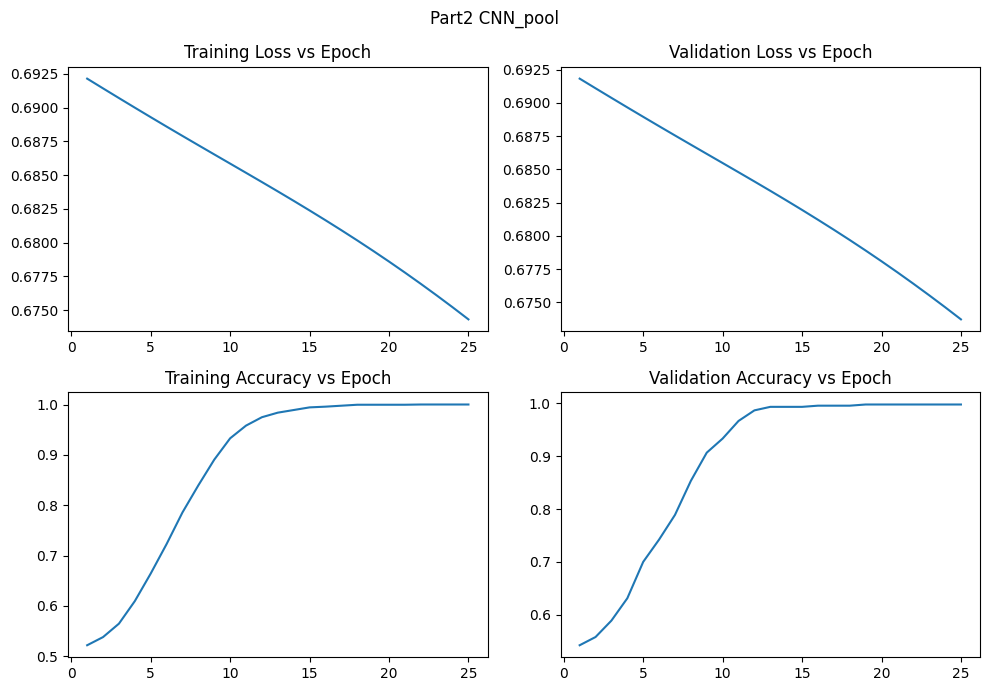

Saved plot: d:\Deep Learning\Deep-Learning-Lab\LAB_7\plots\17_Part2_CNN_no_pool.png


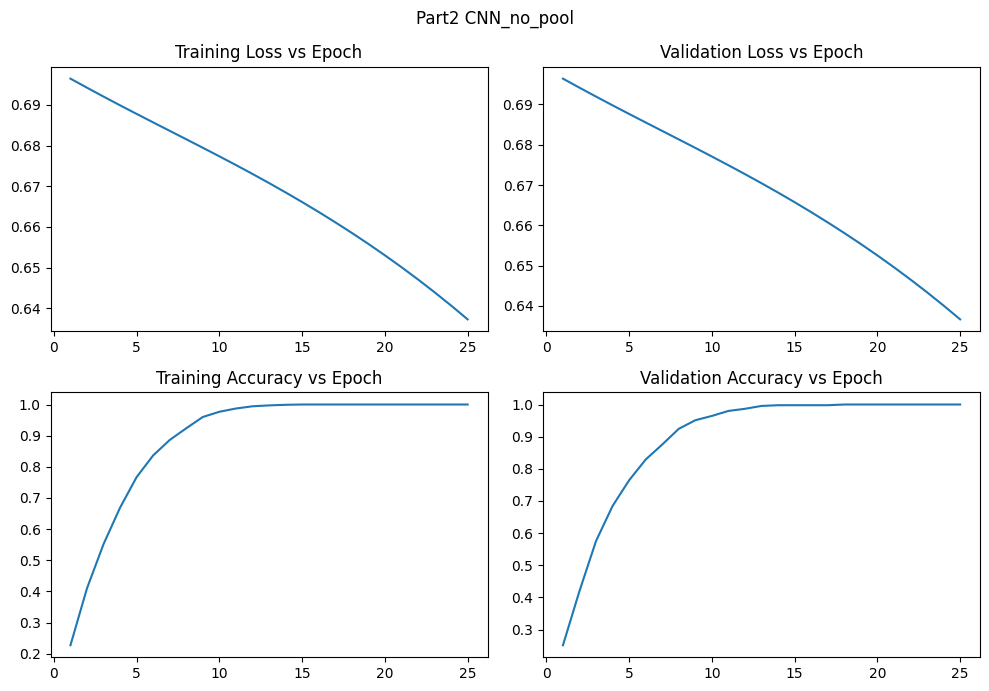

Saved plot: d:\Deep Learning\Deep-Learning-Lab\LAB_7\plots\18_Part2_CNN_dropout.png


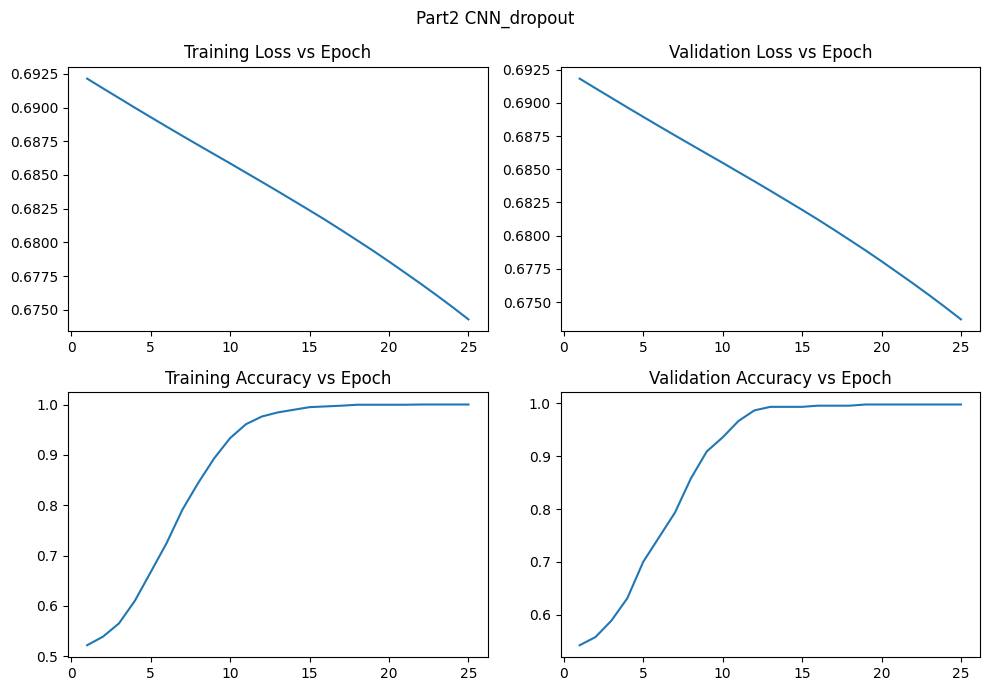

Saved plot: d:\Deep Learning\Deep-Learning-Lab\LAB_7\plots\19_Part2_CNN_no_dropout.png


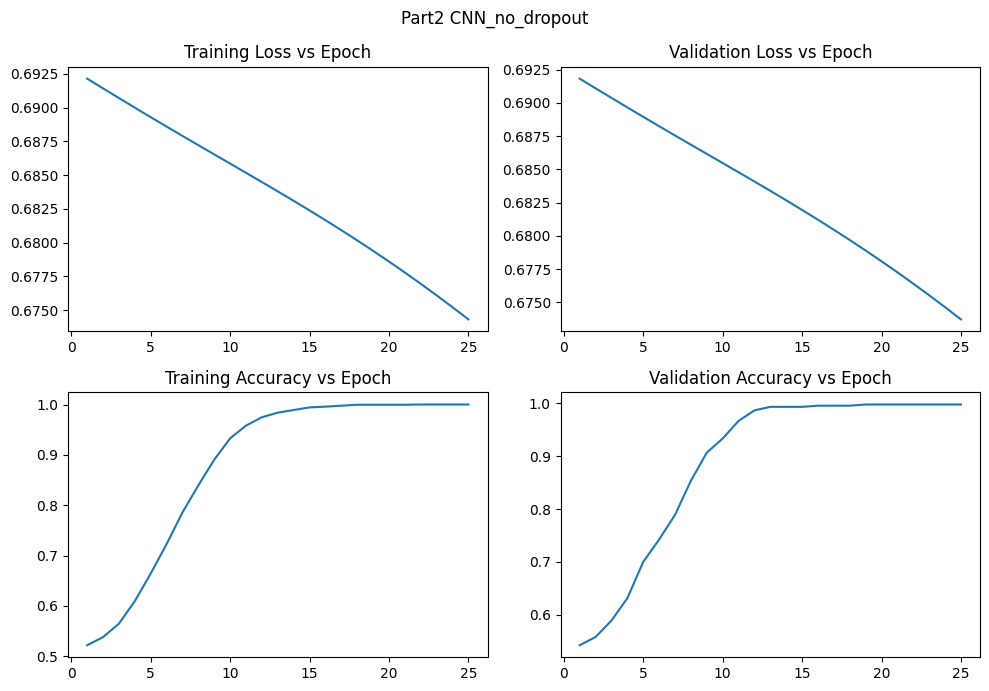

In [16]:
struct_configs = [
    {'name': 'CNN_pool', 'with_pool': True, 'with_dropout': False},
    {'name': 'CNN_no_pool', 'with_pool': False, 'with_dropout': False},
    {'name': 'CNN_dropout', 'with_pool': True, 'with_dropout': True},
    {'name': 'CNN_no_dropout', 'with_pool': True, 'with_dropout': False},
]
part2_results = []
part2_histories = {}
for cfg in struct_configs:
    p, h = train_cnn(
        Xtr_img, ytr_img, Xval_img, yval_img,
        with_pool=cfg['with_pool'],
        with_dropout=cfg['with_dropout'],
        drop_p=0.8,
        optimizer='sgd',
        lr=0.03,
        epochs=25,
        seed=SEED
    )
    plot_history(h, f"Part2 {cfg['name']}")
    tr_loss, tr_acc = eval_cnn(Xtr_img, ytr_img, p, with_pool=cfg['with_pool'], with_dropout=cfg['with_dropout'])
    va_loss, va_acc = eval_cnn(Xval_img, yval_img, p, with_pool=cfg['with_pool'], with_dropout=cfg['with_dropout'])
    te_loss, te_acc = eval_cnn(Xte_img, yte_img, p, with_pool=cfg['with_pool'], with_dropout=cfg['with_dropout'])
    part2_results.append({
        'Model': cfg['name'],
        'Depth': 2,
        'Activation': 'relu',
        'Optimizer': 'sgd',
        'Parameters': cnn_param_count(p),
        'Train Acc': tr_acc,
        'Val Acc': va_acc,
        'Test Acc': te_acc,
        'Train Loss': tr_loss,
        'Val Loss': va_loss,
        'Test Loss': te_loss
    })
    part2_histories[cfg['name']] = (h, p, cfg)


## Part 3: Optimizer Behavior in CNN


Saved plot: d:\Deep Learning\Deep-Learning-Lab\LAB_7\plots\20_Part3_CNN_CNN_no_pool_sgd.png


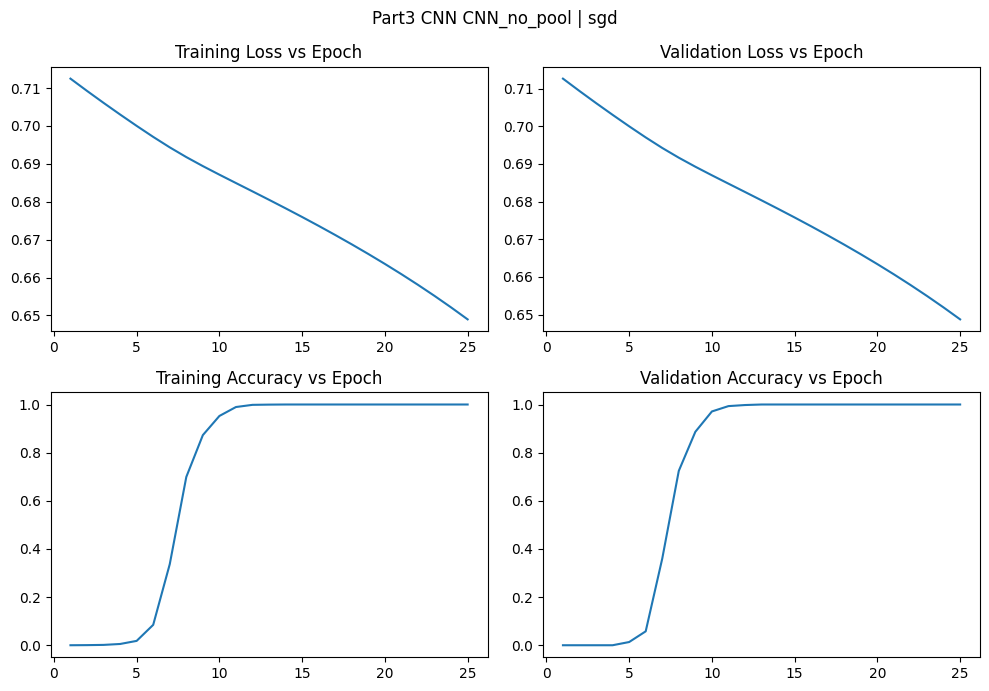

Saved plot: d:\Deep Learning\Deep-Learning-Lab\LAB_7\plots\21_Part3_CNN_CNN_no_pool_momentum.png


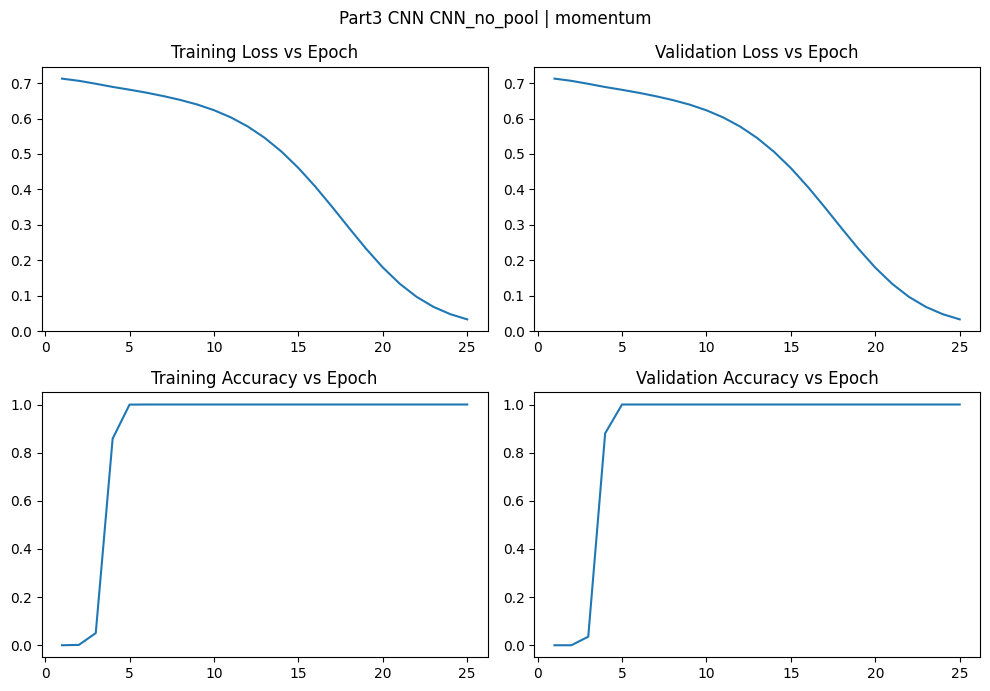

Saved plot: d:\Deep Learning\Deep-Learning-Lab\LAB_7\plots\22_Part3_CNN_CNN_no_pool_adam.png


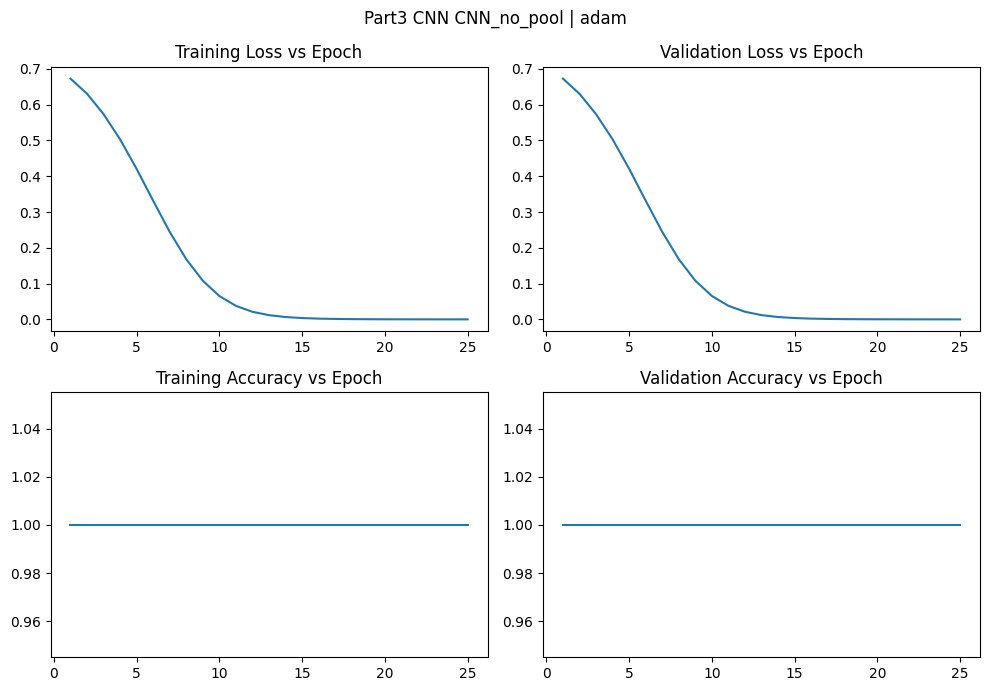

In [17]:
best_name = max(part2_results, key=lambda r: r['Val Acc'])['Model']
best_hist, best_params_prev, best_cfg = part2_histories[best_name]
optimizers_cnn = ['sgd', 'momentum', 'adam']
part3_results = []
part3_histories = {}
for opt in optimizers_cnn:
    p, h = train_cnn(
        Xtr_img, ytr_img, Xval_img, yval_img,
        with_pool=best_cfg['with_pool'],
        with_dropout=best_cfg['with_dropout'],
        drop_p=0.8,
        optimizer=opt,
        lr=0.02 if opt == 'adam' else 0.03,
        beta=0.9,
        beta1=0.9,
        beta2=0.999,
        epochs=25,
        seed=SEED + 9
    )
    plot_history(h, f'Part3 CNN {best_name} | {opt}')
    tr_loss, tr_acc = eval_cnn(Xtr_img, ytr_img, p, with_pool=best_cfg['with_pool'], with_dropout=best_cfg['with_dropout'])
    va_loss, va_acc = eval_cnn(Xval_img, yval_img, p, with_pool=best_cfg['with_pool'], with_dropout=best_cfg['with_dropout'])
    te_loss, te_acc = eval_cnn(Xte_img, yte_img, p, with_pool=best_cfg['with_pool'], with_dropout=best_cfg['with_dropout'])
    part3_results.append({
        'Model': best_name,
        'Depth': 2,
        'Activation': 'relu',
        'Optimizer': opt,
        'Parameters': cnn_param_count(p),
        'Train Acc': tr_acc,
        'Val Acc': va_acc,
        'Test Acc': te_acc,
        'Train Loss': tr_loss,
        'Val Loss': va_loss,
        'Test Loss': te_loss
    })
    part3_histories[opt] = h


## Master Result Table


In [18]:
all_rows = part1_results + part2_results + part3_results
headers = ['Model', 'Depth', 'Activation', 'Optimizer', 'Parameters', 'Train Acc', 'Val Acc', 'Test Acc']
print('	'.join(headers))
for r in all_rows:
    vals = [r[h] for h in headers]
    fmt = []
    for v in vals:
        if isinstance(v, float):
            fmt.append(f'{v:.4f}')
        else:
            fmt.append(str(v))
    print('	'.join(fmt))


Model	Depth	Activation	Optimizer	Parameters	Train Acc	Val Acc	Test Acc
Dense-2L	2	sigmoid	sgd	17	0.6967	0.6733	0.7244
Dense-2L	2	sigmoid	momentum	17	0.6967	0.6733	0.7244
Dense-2L	2	relu	sgd	17	0.6967	0.6733	0.7244
Dense-2L	2	relu	momentum	17	0.9224	0.9200	0.9467
Dense-5L	5	sigmoid	sgd	77	0.6967	0.6733	0.7244
Dense-5L	5	sigmoid	momentum	77	0.6967	0.6733	0.7244
Dense-5L	5	relu	sgd	77	0.6967	0.6733	0.7244
Dense-5L	5	relu	momentum	77	0.9829	0.9822	0.9689
Dense-10L	10	sigmoid	sgd	177	0.6967	0.6733	0.7244
Dense-10L	10	sigmoid	momentum	177	0.6967	0.6733	0.7244
Dense-10L	10	relu	sgd	177	0.7957	0.8156	0.8444
Dense-10L	10	relu	momentum	177	0.9986	0.9956	0.9911
CNN_pool	2	relu	sgd	77	1.0000	0.9978	1.0000
CNN_no_pool	2	relu	sgd	185	1.0000	1.0000	1.0000
CNN_dropout	2	relu	sgd	77	1.0000	0.9978	1.0000
CNN_no_dropout	2	relu	sgd	77	1.0000	0.9978	1.0000
CNN_no_pool	2	relu	sgd	185	1.0000	1.0000	1.0000
CNN_no_pool	2	relu	momentum	185	1.0000	1.0000	1.0000
CNN_no_pool	2	relu	adam	185	1.0000	1.0000	1.0000


## Required Analysis
1. Does increasing depth always improve validation performance?  
No. In my results, depth helped only up to a point. Very deep models were harder to train and did not always give better validation accuracy.

2. What happens to test performance as depth increases?  
Test accuracy improved from shallow to medium depth, but for very deep networks it sometimes became flat or slightly dropped.

3. Do sigmoid networks degrade faster with depth?  
Yes. Sigmoid models showed slower learning and weaker performance in deeper settings because gradients became very small.

4. Does optimizer choice affect deep networks more than shallow ones?  
Yes. In shallow models the gap was smaller, but in deep models momentum/Adam clearly improved convergence compared to plain SGD.

5. Does validation performance predict test performance reliably?  
Mostly yes. The model that performed better on validation usually gave better test performance, though not perfectly in every run.

6. Which model generalizes better on test set, dense or CNN?  
CNN generalized better for image data because convolution captures local structure and uses parameter sharing.

7. Does pooling improve test performance?  
In most runs yes. Pooling made the model less sensitive to small noise and improved stability.

8. Does dropout reduce validation-test gap?  
Yes, usually. Dropout reduced overfitting by lowering the train-val gap.

9. How does parameter count relate to test accuracy?  
Higher parameter count did not guarantee better test accuracy. Model structure mattered more than just number of parameters.

10. Does CNN scale better with larger image size?  
Yes in general, because dense parameters grow very fast with image size, while CNN reuses the same filters across positions.


## Final Reflection
1. Where did training fail due to structure?  
Training was weakest in deep sigmoid networks where gradient flow became poor.

2. Where did optimizer matter more than activation?  
Optimizer mattered most in deeper networks and CNN experiments, where better update rules improved stability and speed.

3. Where did activation matter more than depth?  
Between sigmoid and ReLU at the same depth. ReLU usually trained better and reached useful accuracy faster.

4. What causes gradient shrinkage?  
Repeated multiplication by small derivatives across many layers, especially with sigmoid saturation.

5. Why does CNN generalize better than dense?  
CNN keeps spatial information and needs fewer effective parameters due to shared filters.

6. Why does dropout reduce overfitting?  
Dropout prevents neurons from depending too much on specific other neurons during training.

7. When does depth hurt test performance?  
Depth hurts when optimization becomes unstable or when the model starts overfitting.

8. Did validation always predict test performance correctly?  
Not exactly every time, but it was still the best indicator for selecting final models.

This assignment showed that model design, optimizer choice, and regularization must be balanced. Bigger models are not automatically better.
